In [1]:
import subprocess, sys

for pkg in [
    "transformers", "datasets", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "sentencepiece",
    "seaborn", "requests", "ftfy"
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
All packages ready.


In [2]:
import os, json, random, warnings, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
import ftfy
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "Enable GPU: Settings -> Accelerator -> GPU T4"
DEVICE = torch.device("cuda")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")

WORK_DIR  = "/kaggle/working"
LABELS = ["clean", "profanity", "hate_speech", "threat", "identity_attack"]
print(f"Labels: {LABELS}")

Device: cuda (Tesla T4)
Labels: ['clean', 'profanity', 'hate_speech', 'threat', 'identity_attack']


## Load Pre-split Dataset

Loading the already-prepared train / val / test splits directly.

In [3]:
DATA_DIR = "/kaggle/input/datasets/hridayanshu23/hate-speech-en-ne"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_split.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_split.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_split.csv"))

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Split summary:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    en = (df["language"]=="en").sum() if "language" in df.columns else "N/A"
    ne = (df["language"]=="ne").sum() if "language" in df.columns else "N/A"
    cs = (df["language"]=="cs").sum() if "language" in df.columns else "N/A"
    hs = df["hate_speech"].sum()
    print(f"  {name}: {len(df):6,} | EN={en} NE={ne} CS={cs} | "
          f"hate_speech={hs:,} ({100*hs/len(df):.1f}%)")

print("\nLabel distribution (train):")
for lbl in LABELS:
    n = train_df[lbl].sum()
    print(f"  {lbl:20s}: {n:6,} ({100*n/len(train_df):.1f}%)")

Split summary:
  Train: 165,473 | EN=141094 NE=22826 CS=1553 | hate_speech=22,735 (13.7%)
  Val: 20,684 | EN=17587 NE=2902 CS=195 | hate_speech=2,842 (13.7%)
  Test: 20,685 | EN=17688 NE=2804 CS=193 | hate_speech=2,842 (13.7%)

Label distribution (train):
  clean               : 142,039 (85.8%)
  profanity           :  7,562 (4.6%)
  hate_speech         : 22,735 (13.7%)
  threat              :  3,426 (2.1%)
  identity_attack     :  3,428 (2.1%)


## Tokenizer & Dataset

In [4]:
MODEL_NAME = "xlm-roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME} | Vocab: {tokenizer.vocab_size:,}")

for lang, text in [
    ("English",       "I hate people like you, get out"),
    ("Nepali (Dev)",  "तिमि हरु यहाँ बाट जाउ"),
    ("Code-switched", "yo sala banda, I will report you"),
]:
    toks = tokenizer(text, return_tensors="pt")
    print(f"  {lang:20s}: {toks['input_ids'].shape[1]} tokens")


class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts      = df["text"].tolist()
        self.labels     = df[LABELS].values.astype(np.float32)
        self.languages  = df["language"].tolist() if "language" in df.columns else ["en"] * len(df)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.float),
            "language":       self.languages[idx],
        }

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: xlm-roberta-base | Vocab: 250,002
  English             : 10 tokens
  Nepali (Dev)        : 10 tokens
  Code-switched       : 10 tokens


## DataLoaders

In [5]:
BATCH_SIZE = 32
GRAD_ACCUM = 1

train_dataset = HateSpeechDataset(train_df, tokenizer)
val_dataset   = HateSpeechDataset(val_df,   tokenizer)
test_dataset  = HateSpeechDataset(test_df,  tokenizer)

# WeightedRandomSampler: oversample NE + CS rows
lang_series  = train_df["language"] if "language" in train_df.columns else pd.Series(["en"]*len(train_df))
lang_weights = {"en": 1.0, "ne": 10.0, "cs": 8.0}
sample_wts   = lang_series.map(lang_weights).fillna(1.0).values
sampler      = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_wts),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Effective batch size: {BATCH_SIZE}")

Train batches: 5172 | Val: 647 | Test: 647
Effective batch size: 32


## Model & Language-Aware Loss

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, problem_type="multi_label_classification"
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Compute pos_weights from training data
label_counts = train_df[LABELS].sum().values.astype(float)
N            = len(train_df)
pos_weights  = torch.tensor(
    [(N - c) / max(c, 1) for c in label_counts], dtype=torch.float
).to(DEVICE)

class LanguageAwareBCELoss(nn.Module):
    """
    BCEWithLogitsLoss with per-sample language weight:
      English:       1.0x
      Code-switched: 2.5x
      Nepali:        3.0x
    """
    LANG_WEIGHT = {"en": 1.0, "ne": 3.0, "cs": 2.5}

    def __init__(self, pos_weight):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, languages):
        loss = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction="none"
        )
        w = torch.tensor(
            [self.LANG_WEIGHT.get(l, 1.0) for l in languages],
            dtype=torch.float, device=logits.device
        )
        return (loss * w.unsqueeze(1)).mean()


criterion = LanguageAwareBCELoss(pos_weights)
print("\nClass pos_weights:")
for lbl, w in zip(LABELS, pos_weights.cpu()):
    print(f"  {lbl:20s}: {w:.2f}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Total parameters:     278,047,493
Trainable parameters: 278,047,493

Class pos_weights:
  clean               : 0.16
  profanity           : 20.88
  hate_speech         : 6.28
  threat              : 47.30
  identity_attack     : 47.27


## Training — 10 Epochs with Early Stopping

Early stopping patience = 3: training halts if val macro F1 does not improve for 3 consecutive epochs.

In [7]:
EPOCHS       = 10
LR           = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE     = 3   # early stopping: stop after 3 epochs without improvement

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.10 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

SAVE_DIR = os.path.join(WORK_DIR, "hatespeech-best")
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_f1      = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_per_class_f1": []}

print(f"{'='*70}")
print(f"  TRAINING — up to {EPOCHS} epochs | early stopping patience={PATIENCE}")
print(f"  Model: {MODEL_NAME} | LR={LR} | Batch={BATCH_SIZE}")
print(f"{'='*70}\n")


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["labels"].to(device)
            langs = batch["language"]
            out   = model(input_ids=ids, attention_mask=mask)
            loss  = criterion(out.logits, lbls, langs)
            total_loss += loss.item()
            all_logits.append(out.logits.cpu().numpy())
            all_labels.append(lbls.cpu().numpy())
    return (total_loss / len(loader),
            np.concatenate(all_logits), np.concatenate(all_labels))


for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=True)

    for step, batch in pbar:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        lbls  = batch["labels"].to(DEVICE)
        langs = batch["language"]

        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbls, langs)
        loss.backward()
        epoch_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss/(step+1):.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_logits, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    val_preds    = (torch.sigmoid(torch.tensor(val_logits)) >= 0.5).numpy().astype(int)
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    val_per_cls  = f1_score(val_labels, val_preds, average=None,    zero_division=0)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_per_class_f1"].append(val_per_cls.tolist())

    print(f"\nEpoch {epoch}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    for lbl, f1v in zip(LABELS, val_per_cls):
        print(f"  {lbl:20s}: F1={f1v:.4f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✓ Best checkpoint saved (val macro F1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val macro F1: {best_val_f1:.4f}")

  TRAINING — up to 10 epochs | early stopping patience=3
  Model: xlm-roberta-base | LR=2e-05 | Batch=32



Epoch 1/10 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 1/10 | Train Loss: 0.9510 | Val Loss: 0.4458 | Val Macro F1: 0.6181
  clean               : F1=0.9344
  profanity           : F1=0.6081
  hate_speech         : F1=0.6987
  threat              : F1=0.4421
  identity_attack     : F1=0.4071


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.6181)


...


Epoch 9/10 | Train Loss: 0.1148 | Val Loss: 1.0242 | Val Macro F1: 0.7719
  clean               : F1=0.9670
  profanity           : F1=0.7876
  hate_speech         : F1=0.7947
  threat              : F1=0.6360
  identity_attack     : F1=0.6742


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.7719)


Epoch 10/10 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 10/10 | Train Loss: 0.1082 | Val Loss: 0.9654 | Val Macro F1: 0.7699
  clean               : F1=0.9657
  profanity           : F1=0.7924
  hate_speech         : F1=0.7948
  threat              : F1=0.6294
  identity_attack     : F1=0.6673
  No improvement (1/3)

Training complete. Best val macro F1: 0.7719


## Training Curves

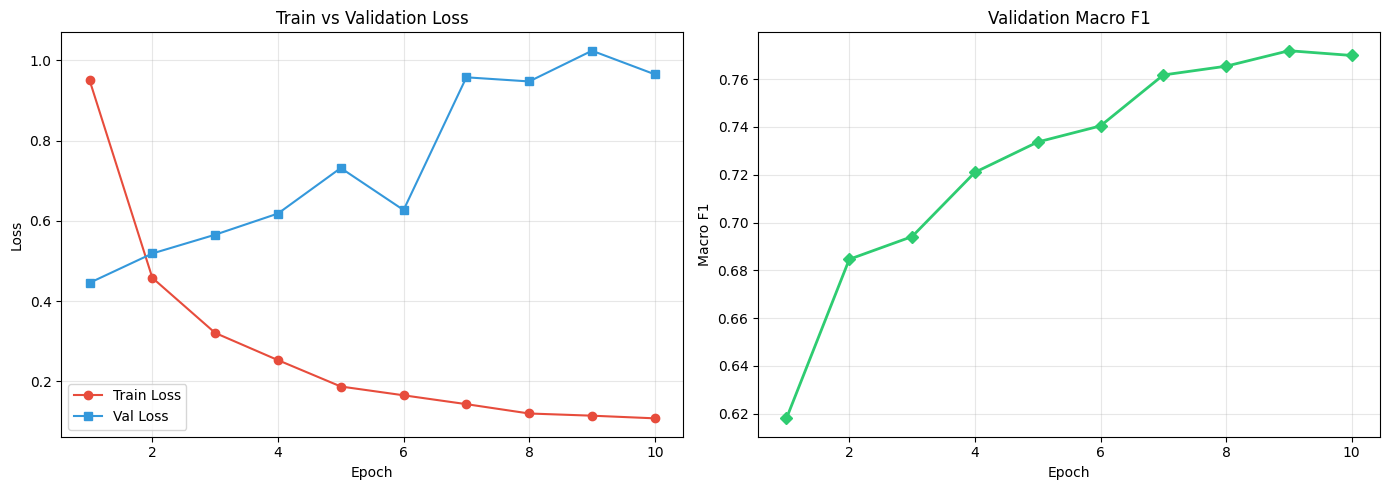

In [8]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history["train_loss"], "o-", label="Train Loss", color="#e74c3c")
ax1.plot(epochs_ran, history["val_loss"],   "s-", label="Val Loss",   color="#3498db")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Train vs Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history["val_macro_f1"], "D-", color="#2ecc71", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro F1"); ax2.set_title("Validation Macro F1")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()

## Per-Language Threshold Tuning

Calibrate per-language thresholds on the validation set to maximise per-language macro F1.

In [9]:
best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
print(f"Best model loaded from {SAVE_DIR}")

best_model.eval()
val_logits_all, val_labels_all, val_langs_all = [], [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        val_logits_all.append(out.logits.cpu().numpy())
        val_labels_all.append(batch["labels"].numpy())
        val_langs_all.extend(batch["language"])

val_logits_all = np.concatenate(val_logits_all)
val_labels_all = np.concatenate(val_labels_all)
val_probs_all  = torch.sigmoid(torch.tensor(val_logits_all)).numpy()
val_langs_all  = np.array(val_langs_all)

THRESHOLDS = {}
THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

print("\nPer-language threshold tuning on validation set:")
for lang in ["en", "ne", "cs"]:
    mask = val_langs_all == lang
    if mask.sum() < 10:
        THRESHOLDS[lang] = 0.5
        print(f"  {lang}: too few samples, using default 0.5")
        continue
    best_f1, best_t = 0.0, 0.5
    for t in THRESHOLD_GRID:
        preds  = (val_probs_all[mask] >= t).astype(int)
        macro  = f1_score(val_labels_all[mask], preds, average="macro", zero_division=0)
        if macro > best_f1:
            best_f1, best_t = macro, t
    THRESHOLDS[lang] = best_t
    print(f"  {lang}: best threshold={best_t:.2f}  (val macro F1={best_f1:.4f})")

print(f"\nFinal thresholds: {THRESHOLDS}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best model loaded from /kaggle/working/hatespeech-best

Per-language threshold tuning on validation set:
  en: best threshold=0.60  (val macro F1=0.7751)
  ne: best threshold=0.65  (val macro F1=0.7736)
  cs: best threshold=0.65  (val macro F1=0.5802)

Final thresholds: {'en': 0.6, 'ne': 0.65, 'cs': 0.65}


## Test Set Evaluation

In [10]:
best_model.eval()
test_logits_all, test_labels_all, test_langs_all = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        test_logits_all.append(out.logits.cpu().numpy())
        test_labels_all.append(batch["labels"].numpy())
        test_langs_all.extend(batch["language"])

test_logits_all = np.concatenate(test_logits_all)
test_labels_arr = np.concatenate(test_labels_all)
test_probs_all  = torch.sigmoid(torch.tensor(test_logits_all)).numpy()
test_langs_all  = np.array(test_langs_all)

# Apply per-language thresholds
test_preds = np.zeros_like(test_probs_all, dtype=int)
for lang, thresh in THRESHOLDS.items():
    mask = test_langs_all == lang
    if mask.sum() > 0:
        test_preds[mask] = (test_probs_all[mask] >= thresh).astype(int)
unlabeled = ~np.isin(test_langs_all, list(THRESHOLDS.keys()))
test_preds[unlabeled] = (test_probs_all[unlabeled] >= 0.5).astype(int)

print("=" * 70)
print("  TEST SET — OVERALL RESULTS (per-language thresholds)")
print("=" * 70)
print(classification_report(test_labels_arr, test_preds, target_names=LABELS, zero_division=0))

overall_macro_f1    = f1_score(test_labels_arr, test_preds, average="macro",    zero_division=0)
overall_weighted_f1 = f1_score(test_labels_arr, test_preds, average="weighted", zero_division=0)
overall_accuracy    = accuracy_score(test_labels_arr.flatten(), test_preds.flatten())
print(f"Overall Accuracy:    {overall_accuracy:.4f}")
print(f"Overall Macro F1:    {overall_macro_f1:.4f}")
print(f"Overall Weighted F1: {overall_weighted_f1:.4f}")

  TEST SET — OVERALL RESULTS (per-language thresholds)
                 precision    recall  f1-score   support

          clean       0.97      0.96      0.97     17751
      profanity       0.72      0.90      0.80       952
    hate_speech       0.79      0.82      0.80      2842
         threat       0.59      0.71      0.65       444
identity_attack       0.60      0.76      0.67       444

      micro avg       0.92      0.93      0.92     22433
      macro avg       0.73      0.83      0.78     22433
   weighted avg       0.92      0.93      0.93     22433
    samples avg       0.93      0.93      0.93     22433

Overall Accuracy:    0.9672
Overall Macro F1:    0.7770
Overall Weighted F1: 0.9272


In [11]:
print("=" * 70)
print("  TEST SET — BY LANGUAGE (with tuned thresholds)")
print("=" * 70)

lang_results = {}
for lang, lang_name in [("en", "English"), ("ne", "Nepali"), ("cs", "Code-switched")]:
    mask = test_langs_all == lang
    if mask.sum() == 0:
        print(f"  {lang_name}: No samples in test set.")
        continue
    l_true  = test_labels_arr[mask]
    l_pred  = test_preds[mask]
    l_macro = f1_score(l_true, l_pred, average="macro", zero_division=0)
    l_per   = f1_score(l_true, l_pred, average=None,    zero_division=0)
    l_acc   = accuracy_score(l_true.flatten(), l_pred.flatten())
    lang_results[lang_name] = {
        "macro_f1": l_macro, "accuracy": l_acc,
        "threshold": THRESHOLDS.get(lang, 0.5),
        "per_class": dict(zip(LABELS, l_per.tolist()))
    }
    print(f"\n  {lang_name} ({mask.sum()} samples | threshold={THRESHOLDS.get(lang,0.5):.2f}):")
    print(f"    Accuracy:  {l_acc:.4f}")
    print(f"    Macro F1:  {l_macro:.4f}")
    for lbl, f1 in zip(LABELS, l_per):
        print(f"      {lbl:20s}: F1={f1:.4f}")

print("\n" + "=" * 50)
print(f"{'Language':<15} {'Accuracy':<12} {'Macro F1':<12} {'Threshold'}")
print("-" * 50)
for ln, res in lang_results.items():
    print(f"{ln:<15} {res['accuracy']:.4f}       {res['macro_f1']:.4f}       {res['threshold']:.2f}")

  TEST SET — BY LANGUAGE (with tuned thresholds)

  English (17688 samples | threshold=0.60):
    Accuracy:  0.9681
    Macro F1:  0.7806
      clean               : F1=0.9704
      profanity           : F1=0.7970
      hate_speech         : F1=0.8165
      threat              : F1=0.6491
      identity_attack     : F1=0.6700

  Nepali (2804 samples | threshold=0.65):
    Accuracy:  0.9591
    Macro F1:  0.7131
      clean               : F1=0.9444
      profanity           : F1=0.7312
      hate_speech         : F1=0.7282
      threat              : F1=0.5902
      identity_attack     : F1=0.5714

  Code-switched (193 samples | threshold=0.65):
    Accuracy:  1.0000
    Macro F1:  0.6000
      clean               : F1=1.0000
      profanity           : F1=1.0000
      hate_speech         : F1=1.0000
      threat              : F1=0.0000
      identity_attack     : F1=0.0000

Language        Accuracy     Macro F1     Threshold
--------------------------------------------------
English 

## Evaluation Plots

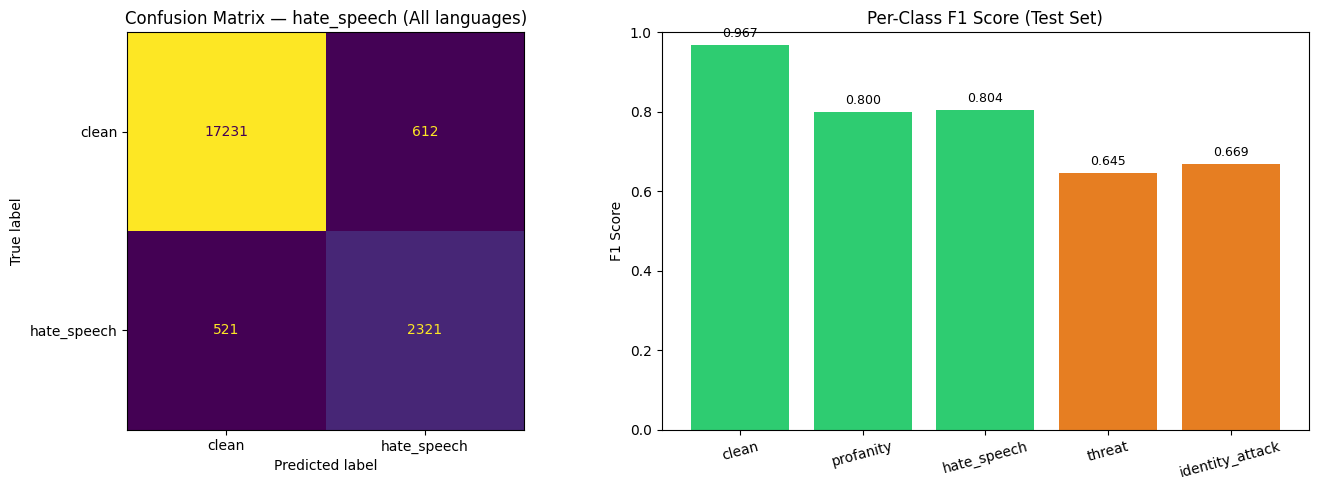

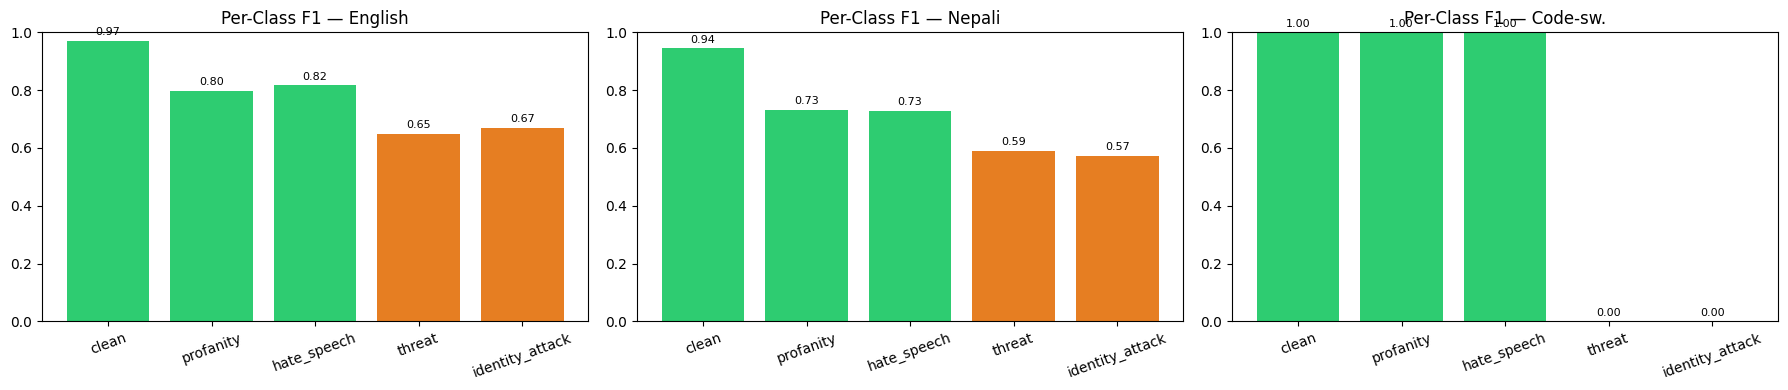

In [12]:
hs_idx  = LABELS.index("hate_speech")
hs_true = test_labels_arr[:, hs_idx].astype(int)
hs_pred = test_preds[:, hs_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(hs_true, hs_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["clean", "hate_speech"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — hate_speech (All languages)")

final_per_cls = f1_score(test_labels_arr, test_preds, average=None, zero_division=0)
colors = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in final_per_cls]
axes[1].bar(LABELS, final_per_cls, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score (Test Set)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(final_per_cls):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "test_evaluation.png"), dpi=100, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, (lang, lang_name) in zip(axes2, [("en","English"),("ne","Nepali"),("cs","Code-sw.")]):
    mask = test_langs_all == lang
    if mask.sum() == 0:
        ax.set_visible(False); continue
    per_cls = f1_score(test_labels_arr[mask], test_preds[mask], average=None, zero_division=0)
    colors2 = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in per_cls]
    ax.bar(LABELS, per_cls, color=colors2)
    ax.set_ylim(0, 1); ax.set_title(f"Per-Class F1 — {lang_name}")
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(per_cls):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "per_language_f1.png"), dpi=100, bbox_inches="tight")
plt.show()

## Save Model & Metrics

In [13]:
FINAL_DIR = os.path.join(WORK_DIR, "guardmeet-xlmr-final")
os.makedirs(FINAL_DIR, exist_ok=True)
best_model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

with open(os.path.join(FINAL_DIR, "label_map.json"), "w") as f:
    json.dump({i: lbl for i, lbl in enumerate(LABELS)}, f, indent=2)

with open(os.path.join(FINAL_DIR, "thresholds.json"), "w") as f:
    json.dump(THRESHOLDS, f, indent=2)

metrics_out = {
    "model": MODEL_NAME,
    "epochs_trained": len(history["train_loss"]),
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1_overall": overall_macro_f1,
    "test_weighted_f1": overall_weighted_f1,
    "language_results": lang_results,
    "thresholds": THRESHOLDS,
    "history": history
}
with open(os.path.join(WORK_DIR, "training_metrics.json"), "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Model + thresholds saved to {FINAL_DIR}")
print(f"Metrics saved to training_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + thresholds saved to /kaggle/working/guardmeet-xlmr-final
Metrics saved to training_metrics.json


## Sample Inference

In [14]:
def detect_script(text):
    dev = sum(1 for c in text if '\u0900' <= c <= '\u097F')
    lat = sum(1 for c in text if c.isascii() and c.isalpha())
    if dev > 0 and lat > 0:
        return "cs"
    elif dev > lat:
        return "ne"
    else:
        t = text.lower()
        ne_markers = ["bro","yaar","ni","ta","ko","ma","le","lai",
                      "cha","chha","ho","gara","garnu","kasto","aaja"]
        ne_hits = sum(1 for w in ne_markers if f" {w} " in f" {t} ")
        return "cs" if ne_hits >= 2 else "en"


def predict(text, model, tokenizer, thresholds=THRESHOLDS):
    model.eval()
    lang = detect_script(text)
    thresh = thresholds.get(lang, 0.5)
    enc = tokenizer(
        text, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        ).logits
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    return {
        "language": lang,
        "threshold_used": thresh,
        "labels": {
            lbl: {"prob": float(f"{p:.4f}"), "flagged": bool(p >= thresh)}
            for lbl, p in zip(LABELS, probs)
        }
    }


demo_sentences = [
    ("English — hate",           "I hate people like you, get out of here"),
    ("English — threat",         "I will hurt you if you say that again"),
    ("English — clean",          "Great meeting everyone, see you next week!"),
    ("Nepali — hate (Devanag)",  "तिमि हरु यहाँ बाट जाउ, मलाई घृणा लाग्छ"),
    ("Nepali — CLEAN",           "यस्ता नेता भय पो हून्छ देस मा बिकास।"),
    ("Code-switch — hate",       "yo sala banda, get out of this meeting"),
    ("Code-switch — clean",      "bro can you share screen, mero side ma dekhena"),
    ("Code-switch — profanity",  "kasto bakwas presentation ho yaar, total faltoo"),
    ("Romanized NE — clean",     "aaja meeting kati bajey start hunchha bro?"),
]

print("=" * 75)
print("  SAMPLE INFERENCE (per-language thresholds applied)")
print("=" * 75)

for label, text in demo_sentences:
    result  = predict(text, best_model, tokenizer)
    lbls    = result["labels"]
    flagged = [k for k, v in lbls.items() if v["flagged"] and k != "clean"]
    top     = max(lbls.items(), key=lambda x: x[1]["prob"])
    print(f"\n[{label}]")
    print(f"  Text      : {text[:65]}")
    print(f"  Detected  : {result['language']} | Threshold: {result['threshold_used']:.2f}")
    print(f"  Flagged   : {flagged if flagged else 'none (clean)'}")
    print(f"  Top class : {top[0]} ({top[1]['prob']:.4f})")
    for lbl, v in lbls.items():
        bar  = "|" * int(v["prob"] * 20)
        flag = " <- FLAGGED" if v["flagged"] and lbl != "clean" else ""
        print(f"    {lbl:20s} {v['prob']:.4f} {bar}{flag}")

  SAMPLE INFERENCE (per-language thresholds applied)

[English — hate]
  Text      : I hate people like you, get out of here
  Detected  : en | Threshold: 0.60
  Flagged   : ['hate_speech']
  Top class : hate_speech (0.9924)
    clean                0.0054 
    profanity            0.0050 
    hate_speech          0.9924 ||||||||||||||||||| <- FLAGGED
    threat               0.0177 
    identity_attack      0.0267 

[English — threat]
  Text      : I will hurt you if you say that again
  Detected  : en | Threshold: 0.60
  Flagged   : none (clean)
  Top class : clean (0.9520)
    clean                0.9520 |||||||||||||||||||
    profanity            0.0002 
    hate_speech          0.0218 
    threat               0.0057 
    identity_attack      0.0012 

[English — clean]
  Text      : Great meeting everyone, see you next week!
  Detected  : en | Threshold: 0.60
  Flagged   : none (clean)
  Top class : clean (0.9996)
    clean                0.9996 |||||||||||||||||||
    profanity 